# EDA — AML Transaction Monitoring (IBM HI-Small)

**Goal:** identify which signals separate laundering from normal transactions,
and decide what to build in `features.py`.

**Discipline rule applied throughout:** every statistic that reads the target is
computed on the **training split only**. The test split is untouched until final
evaluation, so feature decisions cannot be influenced by data the model will be
scored on.

**Data:** 5.08M transactions, 10 days, 0.089% laundering (1 in 1,124).

## 1. Setup

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "/Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection")



from aml_detection.config import INTERIM_DATA_DIR
from aml_detection.config import INTERIM_DATA_DIR
from aml_detection.eda import (
    overview, target_balance,
    explore_categorical, explore_numeric, explore_boolean, explore_temporal,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head(3)

5,077,237 rows x 19 columns


,timestamp,src_bank,src_account,dst_bank,dst_account,amount_received,currency_received,amount_paid,currency_paid,payment_format,is_laundering,is_self_loop,is_cross_currency,amount_delta,is_burn_in,src_entity_type,src_bank_country,dst_entity_type,dst_bank_country
0,2022-09-01,32282,32282_801B64CE0,32282,32282_801B64CE0,29294.03,US Dollar,29294.03,US Dollar,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Named,Sole Proprietorship,Named
1,2022-09-01,212818,212818_804B1DF50,212818,212818_804B1DF50,538528.53,Rupee,538528.53,Rupee,Reinvestment,0,True,False,0.0,True,Partnership,India,Partnership,India
2,2022-09-01,16927,16927_8062913A0,28,28_806291440,96718657.00,Ruble,96718657.00,Ruble,ACH,0,False,False,0.0,True,Partnership,Russia,Partnership,Australia


## 2. Temporal split — before any target-aware analysis

A random split would leak: laundering here is multi-step chains, so random
assignment puts earlier legs in train and later legs in test. A time-based
split mirrors deployment, where the model scores transactions it has never
seen from a period after training.

In [5]:
SPLIT = df.timestamp.quantile(0.70)

train = df[df.timestamp <= SPLIT].copy()
test  = df[df.timestamp >  SPLIT].copy()   # DO NOT TOUCH until final evaluation

print(f"split at {SPLIT}")
print(f"train {len(train):,} rows | {train.is_laundering.sum():,} positives | {train.is_laundering.mean():.4%}")
print(f"test  {len(test):,} rows | {test.is_laundering.sum():,} positives | {test.is_laundering.mean():.4%}")

split at 2022-09-07 14:52:12
train 3,554,066 rows | 2,856 positives | 0.0804%
test  1,523,171 rows | 1,666 positives | 0.1094%


## 3. Structural overview

In [6]:
overview(train)

,dtype,nulls,null_pct,unique,unique_pct,example
timestamp,datetime64[ns],0,0.0,9533,2.682280e-03,2022-09-01 00:00:00
src_bank,int64,0,0.0,30470,8.573279e-03,32282
src_account,object,0,0.0,493790,1.389366e-01,32282_801B64CE0
dst_bank,int64,0,0.0,15811,4.448707e-03,32282
dst_account,object,0,0.0,419919,1.181517e-01,32282_801B64CE0
amount_received,float64,0,0.0,888397,2.499664e-01,29294.03
currency_received,category,0,0.0,15,4.220518e-06,US Dollar
amount_paid,float64,0,0.0,896436,2.522283e-01,29294.03
currency_paid,category,0,0.0,15,4.220518e-06,US Dollar
payment_format,category,0,0.0,7,1.969575e-06,Reinvestment


In [7]:
target_balance(train)

2026-08-16 19:29:32.505 | INFO     | aml_detection.eda:target_balance:56 - 2,856 positives in 3,554,066 rows (0.0804%). 1 in 1,244.
2026-08-16 19:29:32.530 | WARNING  | aml_detection.eda:target_balance:61 - Severe imbalance: ROC-AUC will look flattering and mean little. Report PR-AUC and recall at a fixed alert budget instead.


rows         3.554066e+06
positives    2.856000e+03
rate         8.035867e-04
dtype: float64

**Observation.** 2,856 positives in 3.55M rows — 1 in 1,244.

**Implication.** ROC-AUC will look flattering and mean little at this
imbalance. Headline metrics: **PR-AUC** and **recall at a fixed alert budget**
(how much laundering is caught if investigators can review N alerts a day).

## 4. `payment_format`

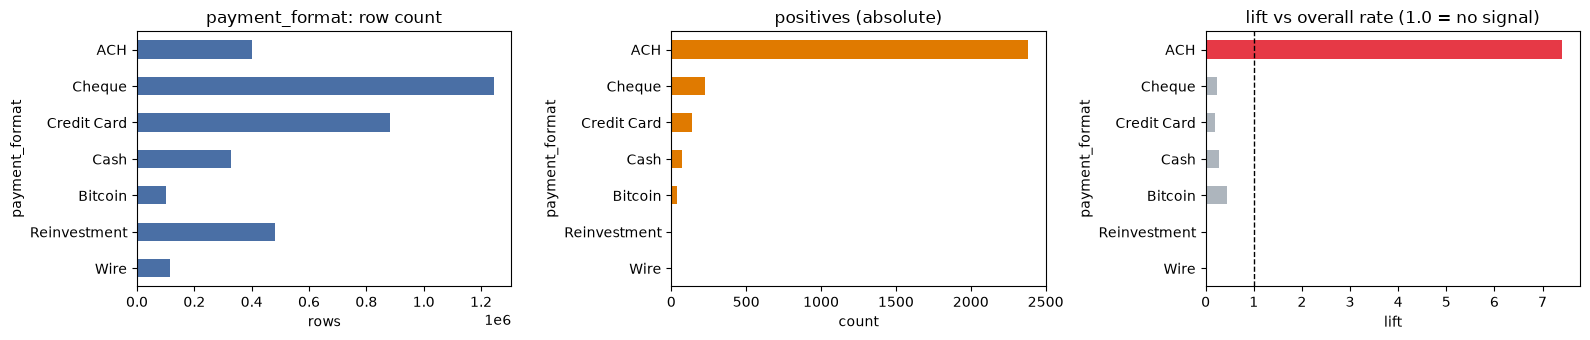

,n,positives,rate,share,lift
payment_format,,,,,
ACH,399953,2381,0.005953,0.112534,7.408286
Cheque,1243542,226,0.000182,0.349893,0.226160
Credit Card,883291,139,0.000157,0.248530,0.195830
Cash,327864,74,0.000226,0.092250,0.280870
Bitcoin,102085,36,0.000353,0.028723,0.438842
Reinvestment,481056,0,0.000000,0.135354,0.000000
Wire,116275,0,0.000000,0.032716,0.000000


In [8]:
explore_categorical(train, "payment_format")

**What the graph shows**

| format | rows | positives | rate | lift |
|---|---|---|---|---|
| ACH | 400K | 2,381 | 0.60% | **7.3x** |
| Cheque | 1.24M | 226 | 0.02% | 0.2x |
| Credit Card | 883K | 139 | 0.02% | 0.2x |
| Cash | 328K | 74 | 0.02% | 0.3x |
| Bitcoin | 102K | 36 | 0.04% | 0.4x |
| Reinvestment | 481K | **0** | 0% | 0 |
| Wire | 116K | **0** | 0% | 0 |

ACH holds **83% of all laundering** from 11% of rows. Two formats have zero
positives across 597K rows.

**What it means**

Format is the strongest single categorical discriminator. The problem is
closer to "which ACH transactions are suspicious" than "which transactions
are suspicious".

**Decision**

- Include `payment_format` as a feature.
- Exclude Reinvestment and Wire from **training rows** (0.080% -> 0.096%
  positive rate at no information cost).
- Keep all formats in the **scoring** path: production must score everything,
  and zero-Wire-laundering is a simulator artifact. Wires are a primary
  laundering channel in reality.
- Report recall per format at evaluation.

## 5. `amount_paid` — raw

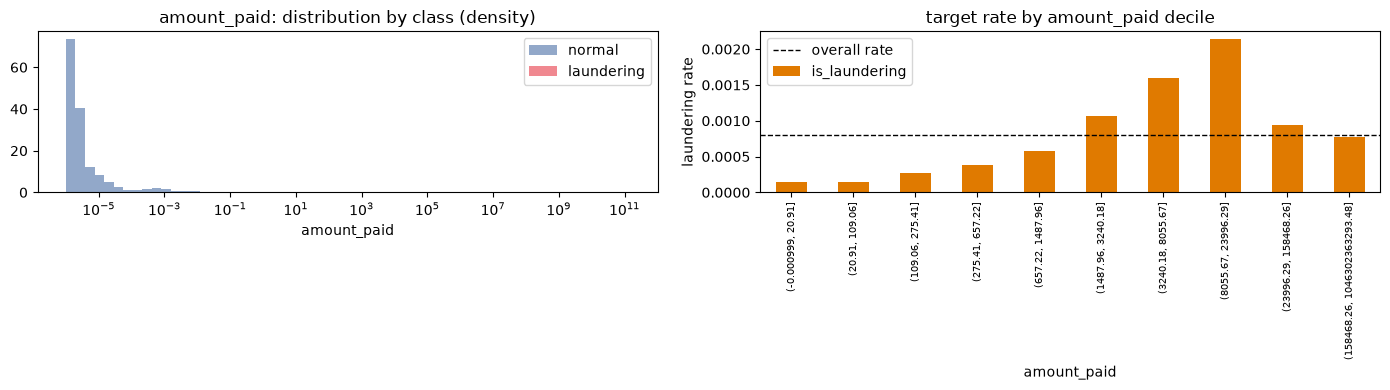

is_laundering,0,1
count,3.551210e+06,2.856000e+03
mean,5.025132e+06,6.406881e+07
std,9.717451e+08,2.056698e+09
min,1.000000e-06,3.227000e-03
25%,1.762600e+02,2.296350e+03
50%,1.484860e+03,7.451100e+03
75%,1.358412e+04,1.872144e+04
95%,7.197996e+05,7.843248e+05
99%,1.515587e+07,2.751157e+07
max,1.046302e+12,8.485314e+10


In [9]:
explore_numeric(train, "amount_paid")

In [10]:
# currency scale check
(train.groupby("currency_paid", observed=True)
   .agg(n=("amount_paid","size"),
        median=("amount_paid","median"),
        laundering=("is_laundering","mean"),
        positives=("is_laundering","sum"))
   .sort_values("n", ascending=False))

,n,median,laundering,positives
currency_paid,,,,
US Dollar,1325768,962.160000,0.000798,1058
Euro,818922,797.950000,0.000880,721
Swiss Franc,164817,843.380000,0.000686,113
Yuan,149563,6360.160000,0.000802,120
Shekel,134447,3316.830000,0.000491,66
Rupee,133220,69166.000000,0.000788,105
UK Pound,126036,732.385000,0.000666,84
Yen,108672,101536.510000,0.000589,64
Ruble,108426,73114.945000,0.000775,84


**What the graph shows**

Currency medians span six orders of magnitude: Bitcoin 0.07, USD 962,
Rupee 69,166, Yen 101,537. The histogram is unreadable as a result.

Within **US Dollar only**:

| percentile | normal | laundering | ratio |
|---|---|---|---|
| 25% | 153 | 1,898 | 12x |
| 50% | 960 | 4,995 | 5x |
| 75% | 6,024 | 12,817 | 2x |
| 95% | 224,277 | 27,523 | **0.12x** |

**What it means**

Raw amount is not comparable across rows — the column mixes currencies with no
exchange rates available.

The signal is a **band**, not a magnitude. Laundering is rarely small and
rarely very large. This is consistent with **structuring**: large enough to be
worth moving, small enough to avoid the scrutiny the largest transactions
attract.

**Decision.** Do not use raw amount directly. Normalise within currency.

## 6. Rejected hypothesis — cross-currency as a layering signal

Cross-currency movement is a recognised layering technique, so the prior
expectation was an **elevated** laundering rate.

- H0: laundering is independent of whether a transaction crosses currencies
- H1: the two are associated
- Test: **Fisher's exact** (2x2; chosen over chi-square because the expected
  count in the positive/cross-currency cell is small)
- alpha = 0.01

In [11]:
from scipy.stats import chi2_contingency, fisher_exact

table = pd.crosstab(train.is_cross_currency, train.is_laundering)
chi2, p_chi, dof, expected = chi2_contingency(table)
odds, p_fisher = fisher_exact(table)

print(table, "\n")
print("expected counts under H0:\n", expected.round(1), "\n")
print(f"chi-square : chi2={chi2:.2f}, p={p_chi:.3e}")
print(f"fisher     : OR={odds:.4f}, p={p_fisher:.3e}")

is_laundering            0     1
is_cross_currency               
False              3503345  2856
True                 47865     0 

expected counts under H0:
 [[3.5033835e+06 2.8175000e+03]
 [4.7826500e+04 3.8500000e+01]] 

chi-square : chi2=38.01, p=7.030e-10
fisher     : OR=0.0000, p=3.473e-17


2026-08-16 19:31:37.262 | WARNING  | aml_detection.eda:explore_boolean:227 - is_cross_currency=[True] contains ZERO positives. Either the flag is useless, or those rows can be excluded from training entirely.


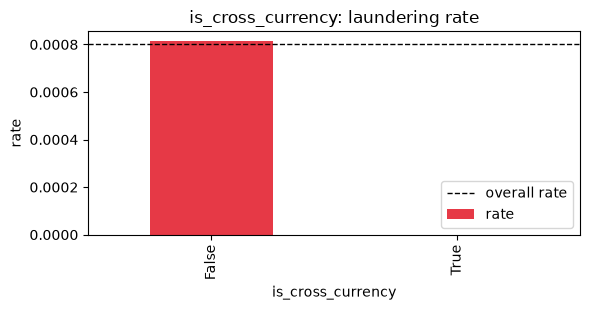

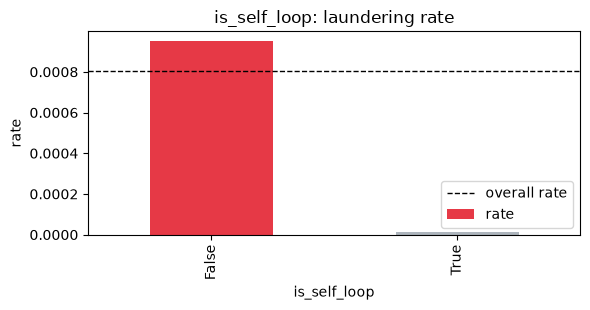

,n,positives,rate,lift
is_self_loop,,,,
False,2995264,2850,0.000952,1.184069
True,558802,6,0.000011,0.013362


In [12]:
explore_boolean(train, "is_cross_currency")
explore_boolean(train, "is_self_loop")

**Result**

|  | expected under H0 | observed |
|---|---|---|
| cross-currency AND laundering | 38.5 | **0** |

- Chi-square: X2 = 38.01, p = 7.03e-10
- Fisher's exact: OR = 0.0000, p = 3.47e-17

H0 rejected by both tests. The two p-values differ by seven orders of
magnitude — the chi-square approximation straining against an empty cell,
which is precisely why Fisher was the appropriate choice.

**Interpretation**

The association is real, not sampling noise. But significance establishes only
that the pattern is unlikely under independence — it does not make the feature
useful. Two reasons to reject it anyway:

1. **Direction contradicts domain knowledge.** A protective effect from
   currency conversion is not plausible behaviour.
2. **A perfectly empty cell across 47,865 rows** is the signature of a
   generator constraint, not a behavioural tendency. Real data would show
   some overlap.

A model trained on this would learn *"cross-currency implies safe"* and would
systematically ignore exactly the transactions an investigator should review.

**Decision.** Drop `is_cross_currency` and `amount_delta`. Exclude self-loop
rows (also 0 positives) from training rather than retaining the flag.

*The test quantifies the effect; domain judgement decides.*

## 7. Account attributes (entity type, bank country)

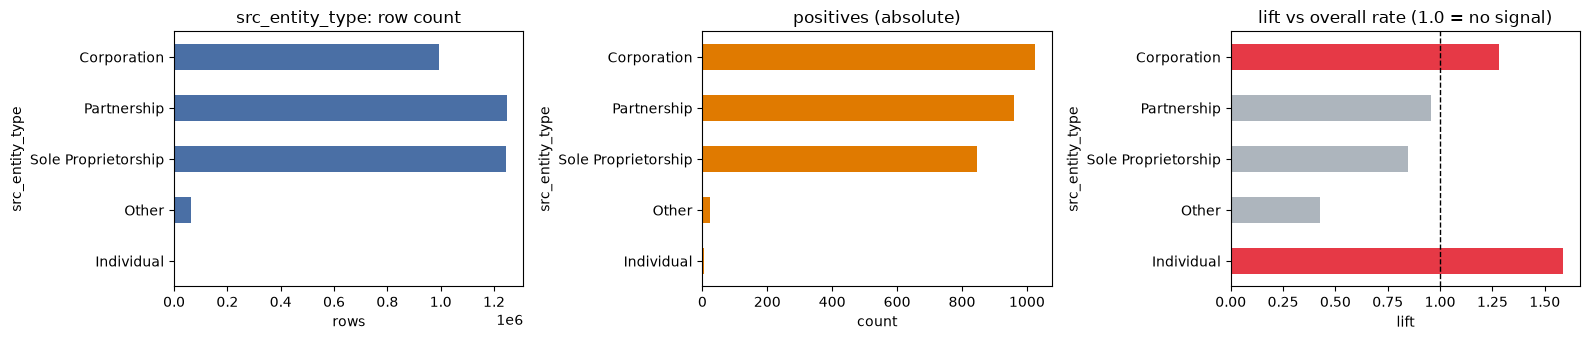

2026-08-16 19:31:47.481 | INFO     | aml_detection.eda:explore_categorical:101 - 5 categories below 500 rows excluded from plot


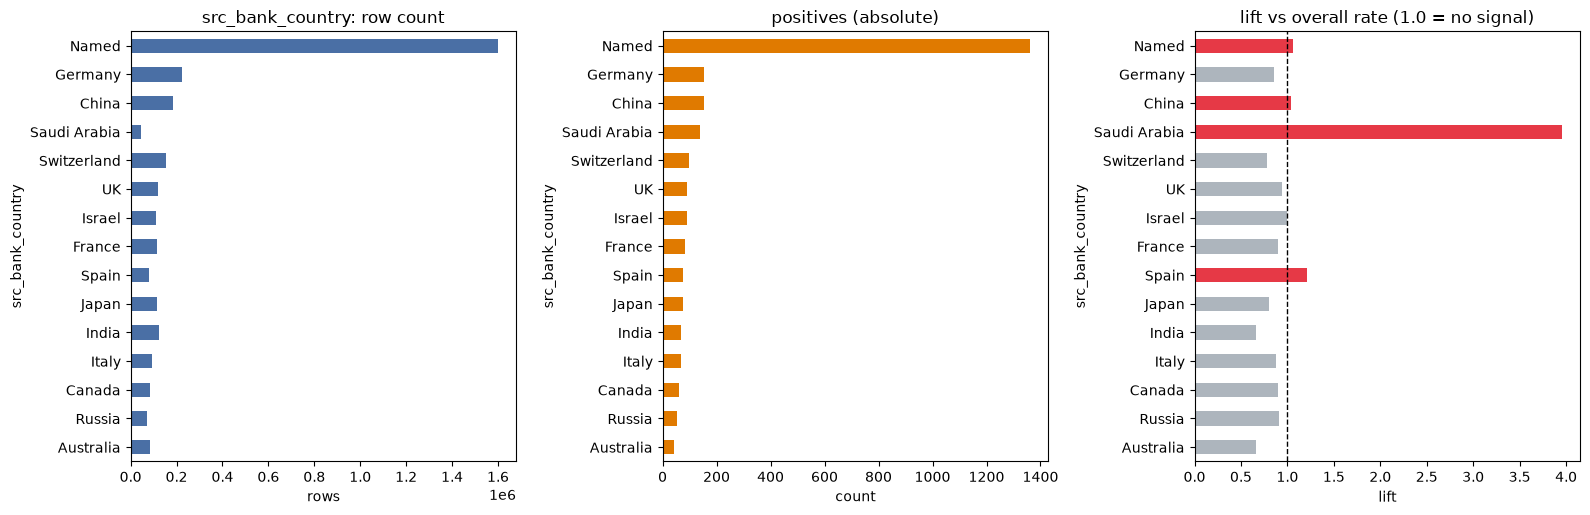

,n,positives,rate,share,lift
src_bank_country,,,,,
Named,1598786,1360,0.000851,0.449847,1.058561
Germany,225050,154,0.000684,0.063322,0.851548
China,182691,152,0.000832,0.051403,1.035366
Saudi Arabia,43767,139,0.003176,0.012315,3.952167
Switzerland,155619,98,0.000630,0.043786,0.783666
UK,119411,90,0.000754,0.033598,0.937919
Israel,112588,90,0.000799,0.031679,0.994759
France,115892,84,0.000725,0.032608,0.901972
Spain,78791,77,0.000977,0.022169,1.216134


In [13]:
explore_categorical(train, "src_entity_type")
explore_categorical(train, "src_bank_country")

**What the graph shows.** Corporation 1.3x, Individual 1.6x (tiny volume),
Saudi Arabia 3.9x on 61,910 rows. Everything else near 1.0.

**What it means.** Static account attributes carry little standalone signal.
The Saudi Riyal effect (0.30% vs 0.08% base) is large enough to be real rather
than noise, but is most likely a simulator choice rather than a fact about
Saudi banking.

**Decision.** Keep provisionally as weak context. **The real signal must come
from behaviour and network structure** — which is what the rest of this
notebook builds.

## 8. Time

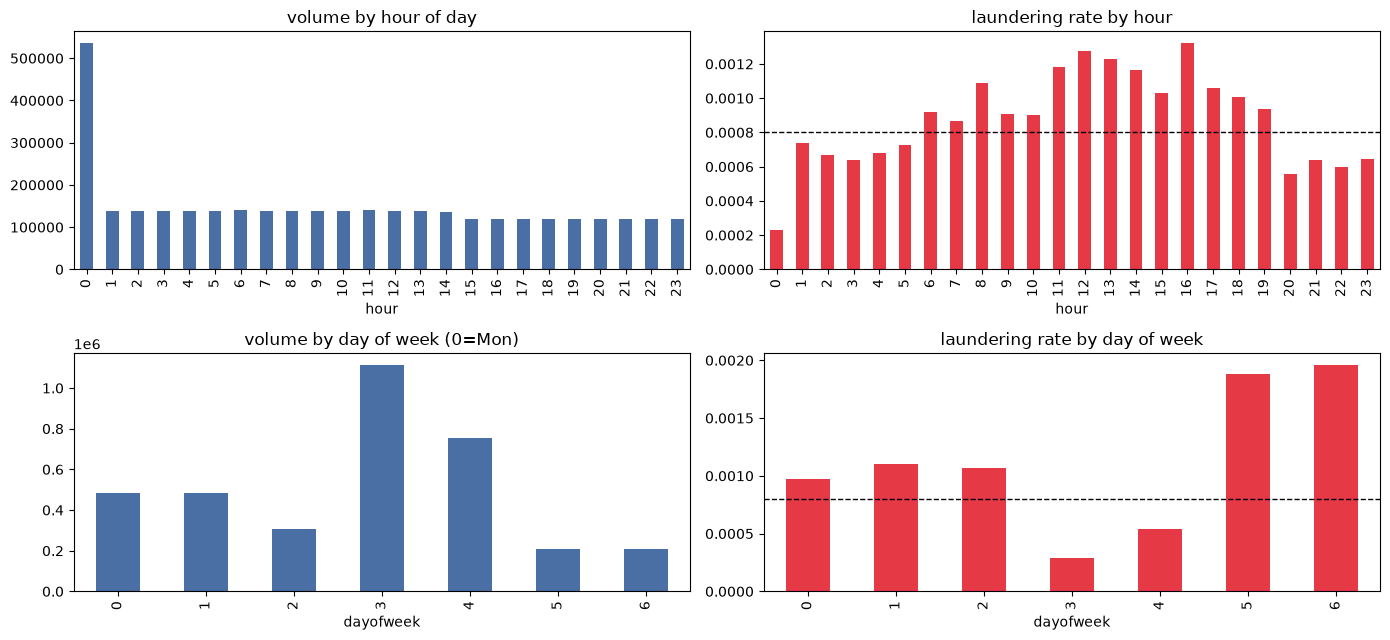

n  positives      rate
unit                                      
hour      0    536869        124  0.000231
          1    139213        103  0.000740
          2    138933         93  0.000669
          3    139198         89  0.000639
          4    138604         94  0.000678
          5    139418        101  0.000724
          6    140234        129  0.000920
          7    139185        121  0.000869
          8    137880        150  0.001088
          9    137915        125  0.000906
          10   138980        125  0.000899
          11   139564        165  0.001182
          12   138471        177  0.001278
          13   138659        170  0.001226
          14   136519        159  0.001165
          15   120461        124  0.001029
          16   119324        158  0.001324
          17   118700        126  0.001061
          18   119054        120  0.001008
          19   119460        112  0.000938
          20   119772         67  0.000559
          21   118887         76  0.000639
          22   118836         71  0.000597
          23   119930         77  0.000642
dayofweek 0    482650        471  0.000976
          1    482089        531  0.001101
          2    305145        326  0.001068
          3   1114921        322  0.000289
          4    754449        408  0.000541
          5    207382        391  0.001885
          6    207430        407  0.001962

In [14]:
explore_temporal(train)

**What the graph shows**

- **Hour:** rate peaks 11:00-16:00 (~0.0013) vs ~0.0002 at hour 0. Volume flat
  except a 4x spike at hour 0.
- **Day of week:** days 5-6 show the highest rates but the **lowest** volume.

**What it means**

Hour-of-day is a genuine behavioural pattern and is knowable at scoring time.

Day-of-week is not trustworthy: the file spans 10 days, so each weekday has
only 1-2 observations, and high rates coincide with low volumes. This reflects
which calendar days the simulation covered, not a weekly banking rhythm.

The hour-0 volume spike is likely a default timestamp for records without a
precise time.

**Decision.** Build `hour_sin`/`hour_cos` (cyclical, so 23:00 and 00:00 are
adjacent) and an `is_hour_zero` flag for "time unknown". Do **not** build
day-of-week. Never use absolute date or days-since-file-start — those encode
position within this file and cannot exist in production.

# Feature engineering

## 9. Amount normalised within currency

Two candidates, since raw amount is not comparable across currencies.

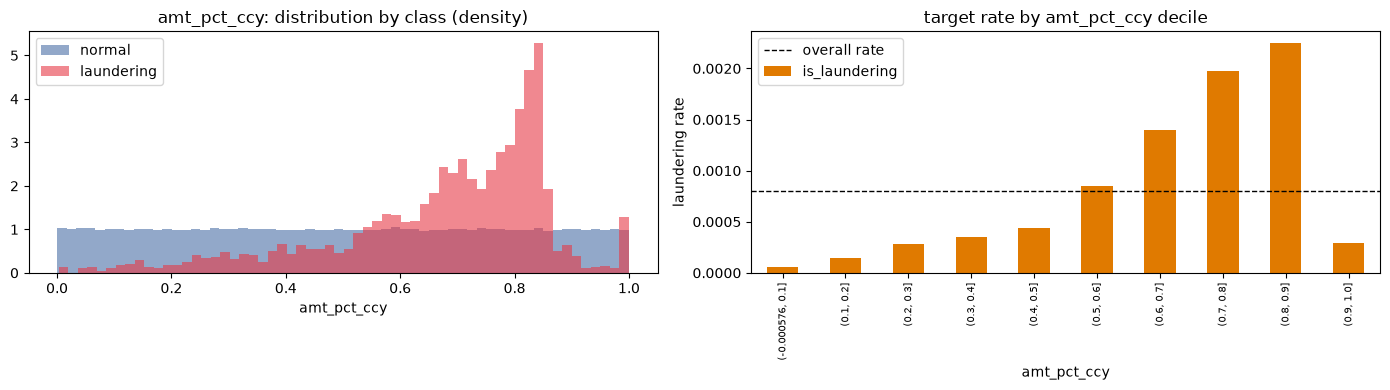

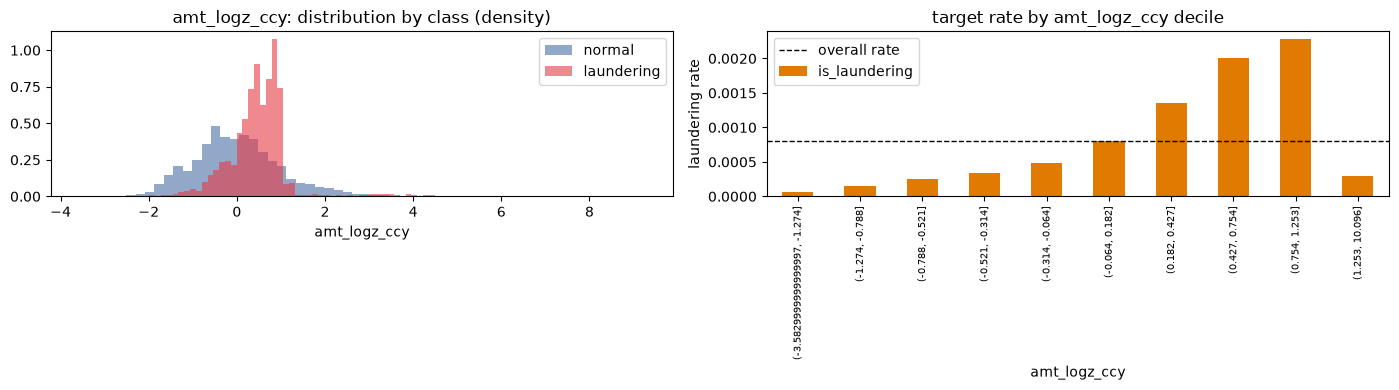

is_laundering,0,1
count,3.551210e+06,2856.000000
mean,-3.872635e-04,0.481532
std,1.000111e+00,0.697342
min,-3.581627e+00,-2.251844
25%,-6.448989e-01,0.159073
50%,-6.465909e-02,0.500413
75%,5.677812e-01,0.832204
95%,1.811841e+00,1.082152
99%,2.779553e+00,3.371894
max,1.009617e+01,5.679550


In [15]:
g_amt = train.groupby("currency_paid", observed=True).amount_paid

train["amt_pct_ccy"] = g_amt.rank(pct=True)
train["log_amount"]  = np.log1p(train.amount_paid)

g_log = train.groupby("currency_paid", observed=True).log_amount
train["amt_logz_ccy"] = (
    (train.log_amount - g_log.transform("mean")) / g_log.transform("std")
)

explore_numeric(train, "amt_pct_ccy",  log_scale=False)
explore_numeric(train, "amt_logz_ccy", log_scale=False)

In [16]:
train[["amt_pct_ccy", "amt_logz_ccy"]].corr().round(3)

,amt_pct_ccy,amt_logz_ccy
amt_pct_ccy,1.000,0.955
amt_logz_ccy,0.955,1.000


**Why not a plain z-score on raw amounts?** With a maximum of 1e12, mean and
standard deviation are dominated by outliers — median z lands near -0.12 while
the max reaches 122. Log first, then standardise.

**What the graphs show**

Class separation is visible for the first time. Normal transactions are
uniform across `amt_pct_ccy` by construction, so any departure from flat *is*
the signal — laundering concentrates between 0.6 and 0.85, peaking near 0.8.

| decile | laundering rate |
|---|---|
| 1 (smallest) | 0.00005 |
| 5 | 0.00085 |
| 9 | 0.0022 <- peak |
| 10 (largest) | 0.0003 <- collapse |

The rate rises steadily, peaks at decile 9, then **falls sevenfold** in the top
decile.

**What it means.** The relationship is **non-monotonic**. A linear model on raw
amount would underfit this; tree models handle it natively. This is an argument
for XGBoost over logistic regression as the primary model.

**Redundancy.** The two features correlate at **0.955** — same thing measured
twice.

**Decision**

- **Keep `amt_pct_ccy`** — bounded 0-1, robust to outliers, and requires no
  fitted mean/std to persist (one less train-serve skew risk).
- Drop `amt_logz_ccy` and `log_amount` as redundant.
- Retain raw `amount_paid`; trees may still find useful splits.

*Percentile boundaries are fitted on training data and must be reused at
inference, not recomputed on incoming batches.*

## 10. Account behaviour and network structure

Static attributes were weak, so this is where the remaining signal must come
from.

**The leakage rule:** every feature answers *what did the bank know about this
account immediately BEFORE this transaction?* Any aggregate computed over the
full file would leak the future into every row.

**On performance:** the obvious implementation
(`groupby.apply(lambda s: s.shift().expanding().mean())`) runs a Python
function per group and takes minutes across ~500K accounts. The version below
is fully vectorised: **5.4s on 3.5M rows**.

Expanding `nunique` has no native pandas equivalent. The trick: mark the first
occurrence of each `(src, dst)` pair, then cumsum those firsts within the
sender — two vectorised passes instead of a per-group loop.

In [17]:
def build_account_features(df: pd.DataFrame) -> pd.DataFrame:
    """Account-level history features using ONLY prior transactions."""
    df = df.sort_values("timestamp").reset_index(drop=True)
    src = df.groupby("src_account", sort=False)
    dst = df.groupby("dst_account", sort=False)

    out = {}

    # volume / velocity
    out["src_txn_count_prior"] = src.cumcount()
    cum_sum = src.amount_paid.cumsum() - df.amount_paid
    out["src_amount_mean_prior"] = cum_sum / out["src_txn_count_prior"].replace(0, np.nan)
    out["src_amount_sum_prior"] = cum_sum

    # timing
    out["src_secs_since_last"] = src.timestamp.diff().dt.total_seconds()
    out["dst_secs_since_last"] = dst.timestamp.diff().dt.total_seconds()

    # counterparty breadth (vectorised expanding nunique)
    first_pair = ~df.duplicated(["src_account", "dst_account"])
    running = first_pair.groupby(df.src_account, sort=False).cumsum()
    out["src_unique_dst_prior"] = running - first_pair.astype(int)

    first_pair_in = ~df.duplicated(["dst_account", "src_account"])
    running_in = first_pair_in.groupby(df.dst_account, sort=False).cumsum()
    out["dst_unique_src_prior"] = running_in - first_pair_in.astype(int)

    # fan ratios -> scatter / gather typologies
    out["src_fanout_ratio"] = (
        out["src_unique_dst_prior"] / out["src_txn_count_prior"].replace(0, np.nan)
    )
    dst_count_prior = dst.cumcount()
    out["dst_txn_count_prior"] = dst_count_prior
    out["dst_fanin_ratio"] = (
        out["dst_unique_src_prior"] / dst_count_prior.replace(0, np.nan)
    )

    out["src_is_new"] = out["src_txn_count_prior"] == 0
    out["dst_is_new"] = dst_count_prior == 0

    return df.assign(**out)


train = build_account_features(train)
print(train.shape)

(3554066, 34)


### 10a. Deviation from the account's own baseline

*Is this transaction unusually large **for this particular account**?* A
50,000 transfer is routine for a business and alarming for an account that has
only ever sent 500.

Three iterations were needed:

1. **Ratio** `amount / prior_mean` — unusable, values to 3.5e7.
2. **Log ratio** — better, but centred at **-3** instead of 0. That offset was
   the diagnostic: the arithmetic prior mean was being dragged upward by
   occasional huge transactions, making every normal transaction look small.
3. **Log deviation from the geometric mean** — average the *logs*, then
   subtract. Outliers cannot dominate a geometric mean. Centres at 0 and lifts
   separation from 2.5x to 3.5x.

*General lesson: for multiplicative, heavy-tailed quantities like money, work
in log space for both the value and the average.*

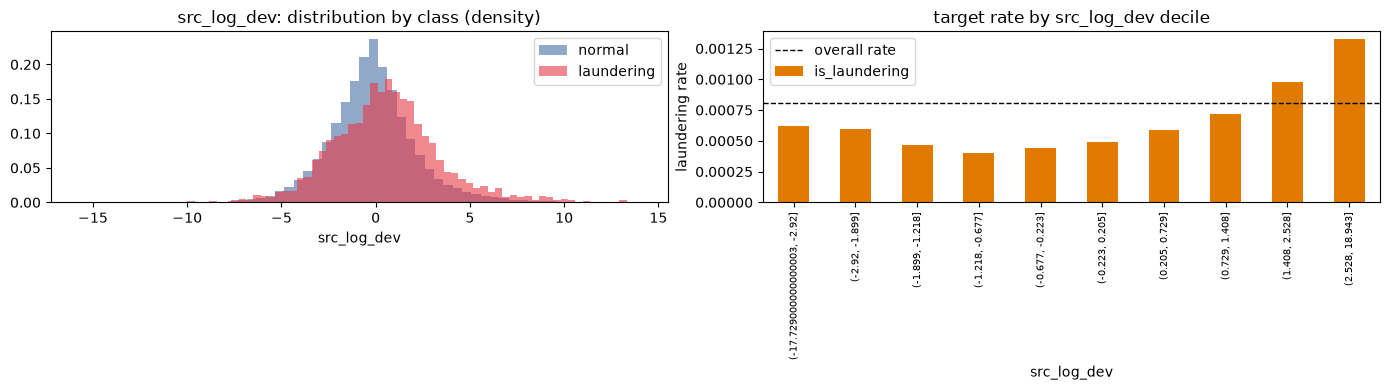

is_laundering,0,1
count,2.627949e+06,1741.000000
mean,-1.856253e-01,0.560717
std,2.325369e+00,2.816524
min,-1.772789e+01,-9.995856
25%,-1.534925e+00,-1.243301
50%,-2.235726e-01,0.498440
75%,1.037861e+00,2.105467
95%,3.739254e+00,5.494338
99%,6.561956e+00,8.965879
max,1.894305e+01,13.317856


In [18]:
train["src_log_amount"] = np.log1p(train.amount_paid)
g = train.groupby("src_account", sort=False)
cum = g.src_log_amount.cumsum() - train.src_log_amount
prior_logmean = cum / train.src_txn_count_prior.replace(0, np.nan)

# require some history: ratios on 1-2 prior transactions are noise
train["src_log_dev"] = np.where(
    train.src_txn_count_prior >= 3,
    train.src_log_amount - prior_logmean,
    np.nan,
)

explore_numeric(train, "src_log_dev", log_scale=False)

**Result.** Centred at 0. Rate falls to 0.00037 in decile 4 and rises to
0.0013 in the top decile — **3.5x spread**, predominantly monotonic.

The absolute-value variant (`src_log_dev.abs()`) was also tested and gave only
2.2x — taking the magnitude discards direction, and direction carries most of
the signal. **Signed version kept.**

### 10b. Network structure — fan-in and fan-out

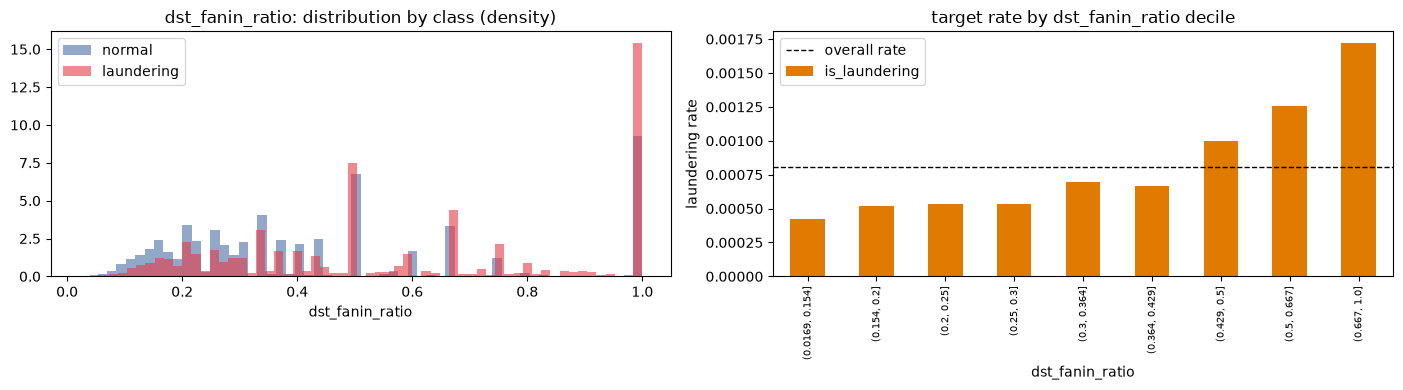

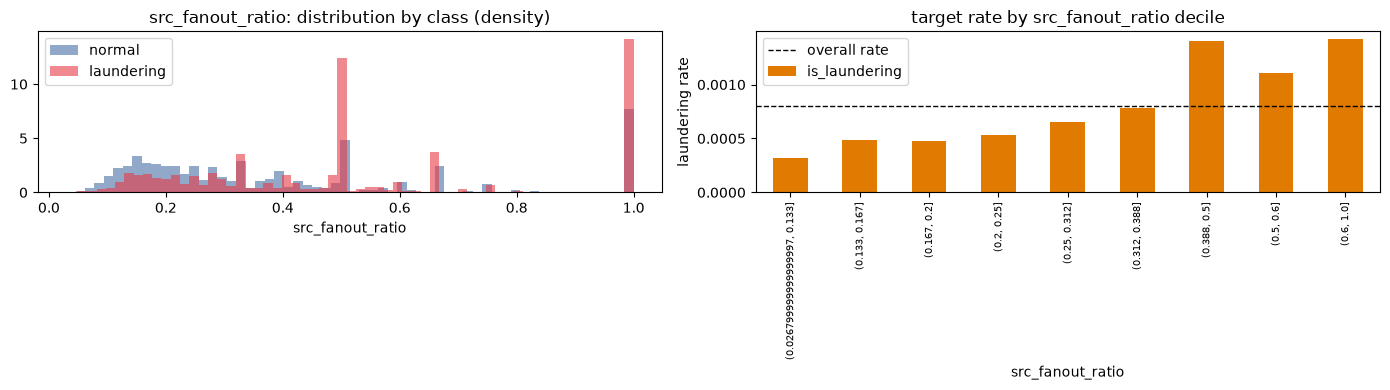

is_laundering,0,1
count,3.057588e+06,2688.000000
mean,4.007073e-01,0.528954
std,2.777632e-01,0.295467
min,2.777778e-02,0.050000
25%,1.842105e-01,0.285714
50%,3.125000e-01,0.500000
75%,5.000000e-01,0.666667
95%,1.000000e+00,1.000000
99%,1.000000e+00,1.000000
max,1.000000e+00,1.000000


In [19]:
explore_numeric(train, "dst_fanin_ratio",  log_scale=False)
explore_numeric(train, "src_fanout_ratio", log_scale=False)

**What the graphs show**

- `dst_fanin_ratio`: 0.00042 -> 0.00172 across deciles (**4x**), cleanly
  monotonic. Laundering piles up at exactly 1.0 (every sender distinct).
- `src_fanout_ratio`: 0.00032 -> 0.0014 (**4.4x**), laundering spikes at 0.5.

**What it means.** These map directly onto laundering typologies:

- **fan-in / gather** — many distinct senders into one account is the
  collection step.
- **fan-out / scatter** — one account paying many distinct accounts is the
  layering step.

**Caveat.** Spikes at 1.0, 0.5, 0.667 are small-denominator artifacts (1/1,
1/2, 2/3) from accounts with few prior transactions. Consider setting the
ratio to NaN below ~3 prior transactions so the model does not read noise as
signal.

**Decision.** Keep both.

### 10c. Timing and account age

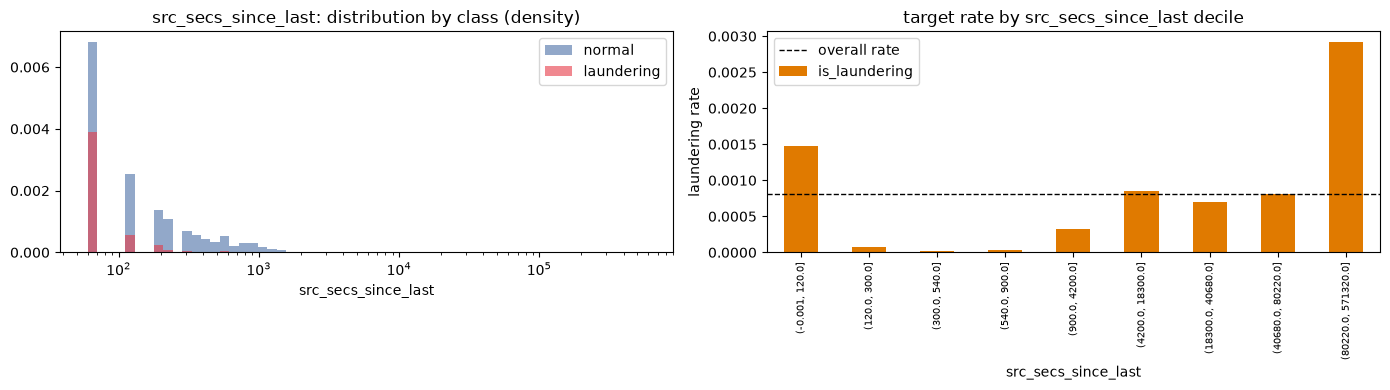

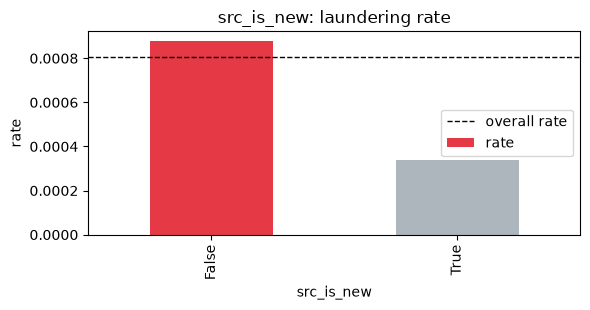

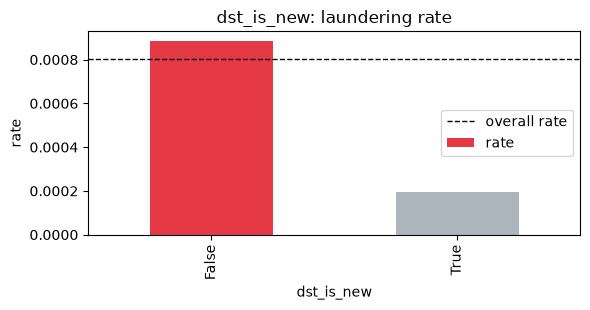

,n,positives,rate,lift
dst_is_new,,,,
False,3134147,2774,0.000885,1.101424
True,419919,82,0.000195,0.243005


In [20]:
explore_numeric(train, "src_secs_since_last", log_scale=True)
explore_boolean(train, "src_is_new")
explore_boolean(train, "dst_is_new")

**`src_secs_since_last` — strongest feature found.**

| window | rate |
|---|---|
| < 120s | 0.0015 |
| 300-900s | ~0.00002 |
| > 80,220s (~22h) | **0.0029** |

**60x spread** between trough and peak — the widest separation of anything
tested. Strongly **U-shaped**, capturing two distinct behaviours:

- **Very fast (<2 min):** rapid pass-through — money arrives and leaves
  immediately. Classic layering.
- **Very slow (>22h):** dormant account suddenly activating. Also a standard
  AML signal.

The safe middle (5-15 min) is ordinary business activity.

**`src_is_new` / `dst_is_new` — reject.** Both show *lower* laundering
(0.00033, 0.00020 vs 0.00088 base). This is mechanical rather than
behavioural: a first transaction has no history so cannot yet be part of a
chain. The direction also contradicts real AML practice, where new accounts
are elevated risk. Keep at most as a "history available" indicator for NaN
handling.

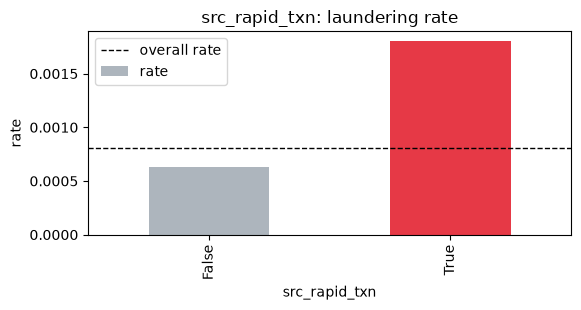

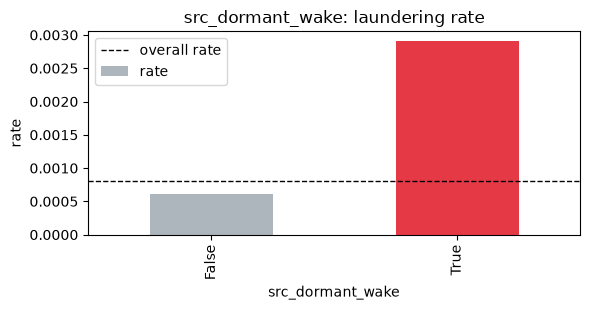

,n,positives,rate,lift
src_dormant_wake,,,,
False,3246747,1962,0.000604,0.752000
True,307319,894,0.002909,3.620057


In [21]:
train["src_secs_since_last_log"] = np.log1p(train.src_secs_since_last)
train["src_rapid_txn"]     = train.src_secs_since_last < 120
train["src_dormant_wake"]  = train.src_secs_since_last > 80_000

explore_boolean(train, "src_rapid_txn")
explore_boolean(train, "src_dormant_wake")

## 11. Correlation — redundancy check

Highly correlated features add training cost and destabilise importance
attribution without adding information.

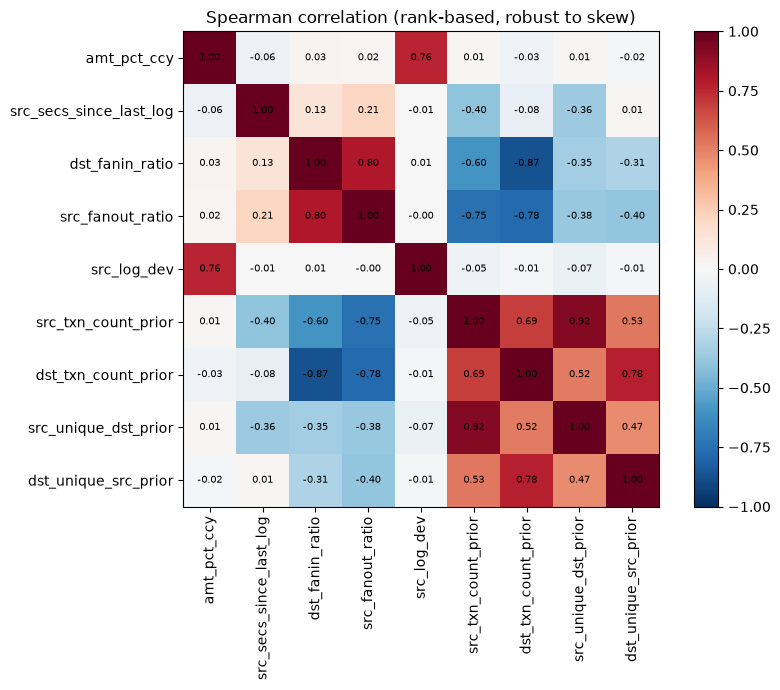

pairs above 0.8:
src_txn_count_prior  src_unique_dst_prior    0.915630
dst_fanin_ratio      dst_txn_count_prior     0.870895
dtype: float64


In [23]:
CANDIDATES = [
    "amt_pct_ccy",
    "src_secs_since_last_log",
    "dst_fanin_ratio",
    "src_fanout_ratio",
    "src_log_dev",
    "src_txn_count_prior",
    "dst_txn_count_prior",
    "src_unique_dst_prior",
    "dst_unique_src_prior",
    #"hour",
]

corr = train[CANDIDATES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CANDIDATES))); ax.set_xticklabels(CANDIDATES, rotation=90)
ax.set_yticks(range(len(CANDIDATES))); ax.set_yticklabels(CANDIDATES)
for i in range(len(CANDIDATES)):
    for j in range(len(CANDIDATES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.title("Spearman correlation (rank-based, robust to skew)")
plt.tight_layout(); plt.show()

# flag redundant pairs
high = (corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False))
print("pairs above 0.8:"); print(high[high > 0.8])

**Note.** Spearman rather than Pearson: these features are heavily skewed and
several relationships are monotonic but not linear.

`src_unique_dst_prior` is expected to correlate strongly with
`src_txn_count_prior` (the numerator of the fan-out ratio). Keep the ratio,
drop whichever raw count adds nothing.

## 12. Feature shortlist

| feature | spread | source | verdict |
|---|---|---|---|
| `src_secs_since_last` | **60x** | timing | keep (U-shaped) |
| `amt_pct_ccy` | **40x** | amount | keep |
| `payment_format` | 7.3x | raw | keep |
| `hour_sin` / `hour_cos` | 6x | time | keep |
| `src_fanout_ratio` | 4.4x | network | keep |
| `dst_fanin_ratio` | 4.0x | network | keep |
| `src_log_dev` | 3.5x | behaviour | keep |
| `src_entity_type`, `src_bank_country` | ~1.3x | account | weak, provisional |

**Rejected**

| feature | reason |
|---|---|
| `is_cross_currency`, `amount_delta` | 0 positives in 47,865 rows; direction contradicts domain knowledge (simulator artifact) |
| `is_self_loop` | 0 positives; exclude those rows instead |
| `amt_logz_ccy`, `log_amount` | r = 0.955 with `amt_pct_ccy` |
| `src_log_dev_abs` | 2.2x vs 3.5x signed — discards direction |
| `src_is_new`, `dst_is_new` | mechanical artifact, wrong direction |
| `day_of_week` | only 10 days of data; calendar artifact |

**Training row exclusions:** Reinvestment, Wire, self-loops (zero positives in
all three).

**Modelling implications**

1. Several relationships are **non-monotonic** (amount band, U-shaped timing).
   Tree ensembles handle these natively — XGBoost over logistic regression as
   the primary model, with LR as an interpretable baseline.
2. At 0.08% positives, report **PR-AUC** and **recall at a fixed alert
   budget**, not ROC-AUC.
3. Two features (`amt_pct_ccy`, and any target encoding) require statistics
   fitted on training data and reused at inference. These must be persisted
   with the model.

**Production note.** These features are computed batch-wise over full history.
In production, account aggregates would be maintained incrementally in a
feature store and read at inference — recomputing over 5M rows per request is
infeasible. The offline definitions here are the specification the online
store must reproduce; keeping them consistent is the primary train-serve skew
risk in this design.

**Next:** port survivors into `features.py`, add a leakage regression test,
then build the rules baseline before any model.

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train[CANDIDATES].dropna()
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=X.columns,
).sort_values(ascending=False)
print(vif)

In [33]:
df = df.sort_values("timestamp").reset_index(drop=True)


In [53]:
src = df.groupby("src_account", sort=False)
dst = df.groupby("dst_account", sort=False)

df["src_secs_since_last"] = src.timestamp.diff().dt.total_seconds()
df["dst_secs_since_last"] = dst.timestamp.diff().dt.total_seconds()

# derived flags
df["src_secs_since_last_log"] = np.log1p(df.src_secs_since_last)
df["src_rapid_txn"]    = df.src_secs_since_last < 120
df["src_dormant_wake"] = df.src_secs_since_last > 80_000

In [54]:
df['src_secs_since_last'].value_counts()

src_secs_since_last
0.0         484367
60.0        276252
120.0       189286
180.0       164273
240.0       147815
             ...  
360600.0         1
756660.0         1
801720.0         1
436860.0         1
863460.0         1
Name: count, Length: 14183, dtype: int64

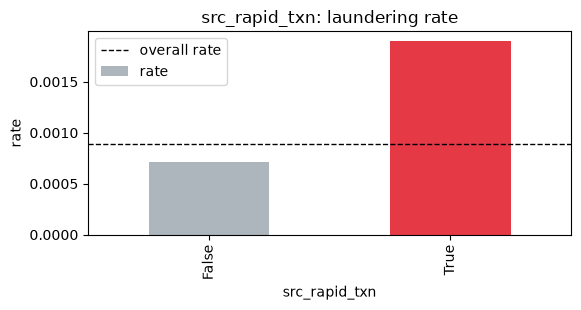

,n,positives,rate,lift
src_rapid_txn,,,,
False,4316618,3077,0.000713,0.800351
True,760619,1445,0.001900,2.133033


In [55]:
explore_boolean(df,"src_rapid_txn")

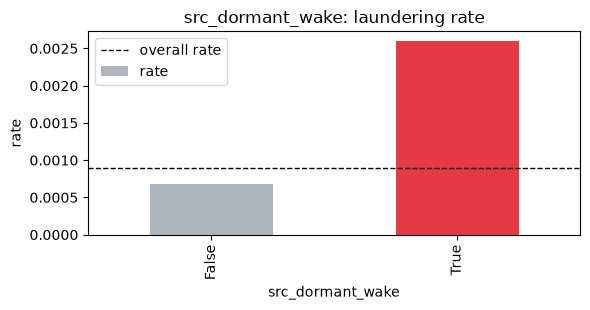

,n,positives,rate,lift
src_dormant_wake,,,,
False,4518623,3070,0.000679,0.762832
True,558614,1452,0.002599,2.918446


In [57]:
explore_boolean(df,"src_dormant_wake")

In [58]:
train.groupby("src_rapid_txn").is_laundering.agg(["size","sum","mean"])
train.groupby("src_dormant_wake").is_laundering.agg(["size","sum","mean"])

,size,sum,mean
src_dormant_wake,,,
False,3246747,1962,0.000604
True,307319,894,0.002909


In [59]:
for t in [60, 120, 300, 600]:
    r = train.assign(f=train.src_secs_since_last < t).groupby("f").is_laundering.mean()
    print(f"<{t}s: lift {r[True]/train.is_laundering.mean():.2f}")
    

<60s: lift 3.26
<120s: lift 2.24
<300s: lift 1.40
<600s: lift 0.97


In [60]:
for t in [10, 20, 30, 45, 60, 90]:
    m = train.src_secs_since_last < t
    print(f"<{t:>3}s: n={m.sum():>7,} pos={train.is_laundering[m].sum():>4} "
          f"lift={train.is_laundering[m].mean()/train.is_laundering.mean():.2f}")
          

< 10s: n=326,004 pos= 853 lift=3.26
< 20s: n=326,004 pos= 853 lift=3.26
< 30s: n=326,004 pos= 853 lift=3.26
< 45s: n=326,004 pos= 853 lift=3.26
< 60s: n=326,004 pos= 853 lift=3.26
< 90s: n=512,762 pos= 925 lift=2.24


In [61]:
for t in [40_000, 60_000, 80_000, 120_000, 200_000]:
    m = train.src_secs_since_last > t
    print(f">{t:>7,}s: n={m.sum():>7,} pos={train.is_laundering[m].sum():>4} "
          f"lift={train.is_laundering[m].mean()/train.is_laundering.mean():.2f}")

> 40,000s: n=620,565 pos=1144 lift=2.29
> 60,000s: n=438,915 pos= 998 lift=2.83
> 80,000s: n=307,319 pos= 894 lift=3.62
>120,000s: n=126,166 pos= 755 lift=7.45
>200,000s: n= 68,652 pos= 570 lift=10.33


In [62]:
for t in [200_000, 300_000, 400_000, 500_000]:
    m = train.src_secs_since_last > t
    print(f">{t:>7,}s: n={m.sum():>7,} pos={train.is_laundering[m].sum():>4} "
          f"lift={train.is_laundering[m].mean()/train.is_laundering.mean():.2f}")

>200,000s: n= 68,652 pos= 570 lift=10.33
>300,000s: n= 23,125 pos= 378 lift=20.34
>400,000s: n= 10,520 pos= 208 lift=24.60
>500,000s: n=  2,913 pos=  41 lift=17.52


In [63]:
train["src_rapid_txn"]    = train.src_secs_since_last <= 60        # same/next minute
train["src_dormant_wake"] = train.src_secs_since_last > 200_000    # >2.3 days


In [64]:
df = df.sort_values("timestamp").reset_index(drop=True)

# ---- outgoing: distinct receivers this sender has paid before ----
first_pair = ~df.duplicated(["src_account", "dst_account"])
running = first_pair.groupby(df.src_account, sort=False).cumsum()
df["src_unique_dst_prior"] = running - first_pair.astype(int)

# ---- incoming: distinct senders this receiver has been paid by before ----
first_pair_in = ~df.duplicated(["dst_account", "src_account"])
running_in = first_pair_in.groupby(df.dst_account, sort=False).cumsum()
df["dst_unique_src_prior"] = running_in - first_pair_in.astype(int)

# ---- transaction counts so far ----
df["src_txn_count_prior"] = df.groupby("src_account", sort=False).cumcount()
df["dst_txn_count_prior"] = df.groupby("dst_account", sort=False).cumcount()

# ---- ratios: distinct counterparties relative to activity ----
# NaN below 3 prior transactions: 1/1 and 1/2 produce spikes at 1.0 and 0.5
# that reflect newness, not fan-out behaviour
df["src_fanout_ratio"] = np.where(
    df.src_txn_count_prior >= 3,
    df.src_unique_dst_prior / df.src_txn_count_prior,
    np.nan,
)
df["dst_fanin_ratio"] = np.where(
    df.dst_txn_count_prior >= 3,
    df.dst_unique_src_prior / df.dst_txn_count_prior,
    np.nan,
)

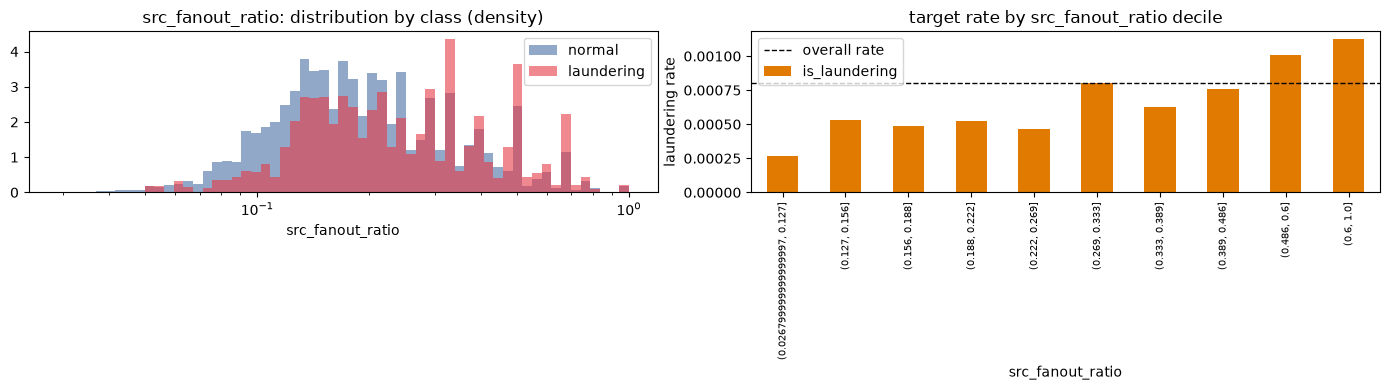

is_laundering,0,1
count,2.627937e+06,1753.000000
mean,3.174028e-01,0.378293
std,1.853663e-01,0.192700
min,2.777778e-02,0.050000
25%,1.709556e-01,0.214286
50%,2.692308e-01,0.333333
75%,4.285714e-01,0.500000
95%,6.666667e-01,0.666667
99%,9.227883e-01,0.986667
max,1.000000e+00,1.000000


In [68]:
train = df[df.timestamp <= SPLIT].copy()
test  = df[df.timestamp >  SPLIT].copy()

explore_numeric(train, "src_fanout_ratio")


NaN share: 0.2600897113334418


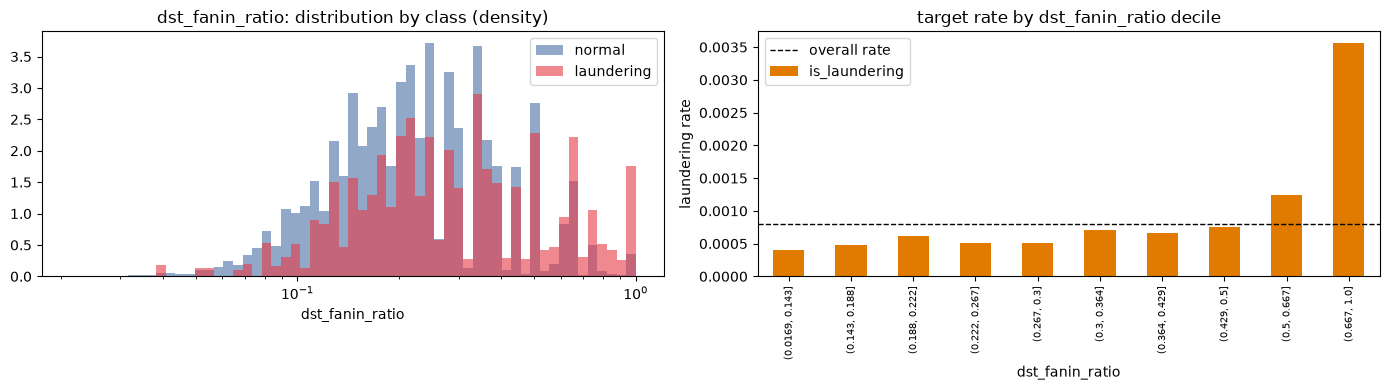

is_laundering,0,1
count,2.601352e+06,2139.000000
mean,3.556392e-01,0.499787
std,1.989699e-01,0.269811
min,1.785714e-02,0.040000
25%,2.000000e-01,0.272727
50%,3.000000e-01,0.444444
75%,5.000000e-01,0.666667
95%,7.500000e-01,1.000000
99%,1.000000e+00,1.000000
max,1.000000e+00,1.000000


In [69]:
print("NaN share:", train.src_fanout_ratio.isna().mean())
explore_numeric(train, "dst_fanin_ratio")

NaN share: 0.2600897113334418


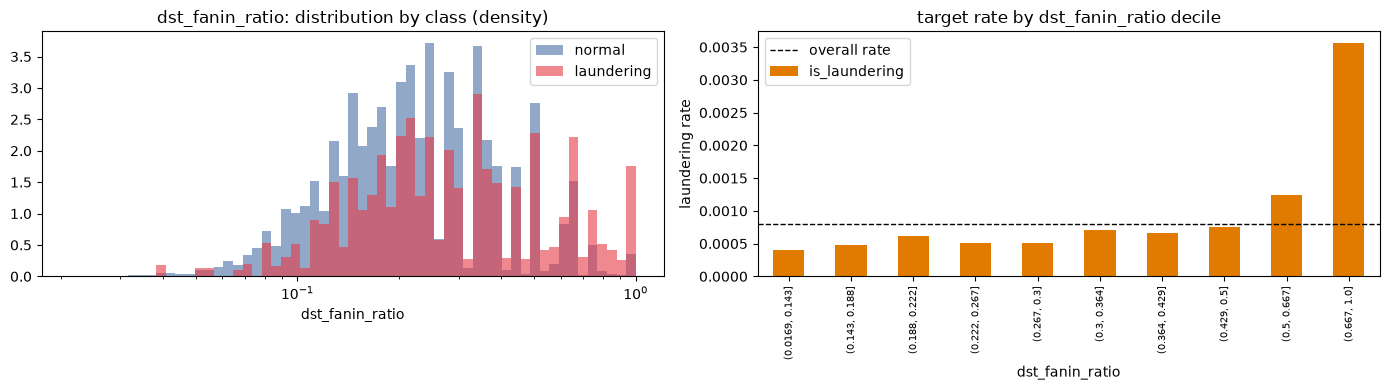

is_laundering,0,1
count,2.601352e+06,2139.000000
mean,3.556392e-01,0.499787
std,1.989699e-01,0.269811
min,1.785714e-02,0.040000
25%,2.000000e-01,0.272727
50%,3.000000e-01,0.444444
75%,5.000000e-01,0.666667
95%,7.500000e-01,1.000000
99%,1.000000e+00,1.000000
max,1.000000e+00,1.000000


In [70]:
print("NaN share:", train.src_fanout_ratio.isna().mean())
explore_numeric(train, "dst_fanin_ratio")

NaN share: 0.2600897113334418


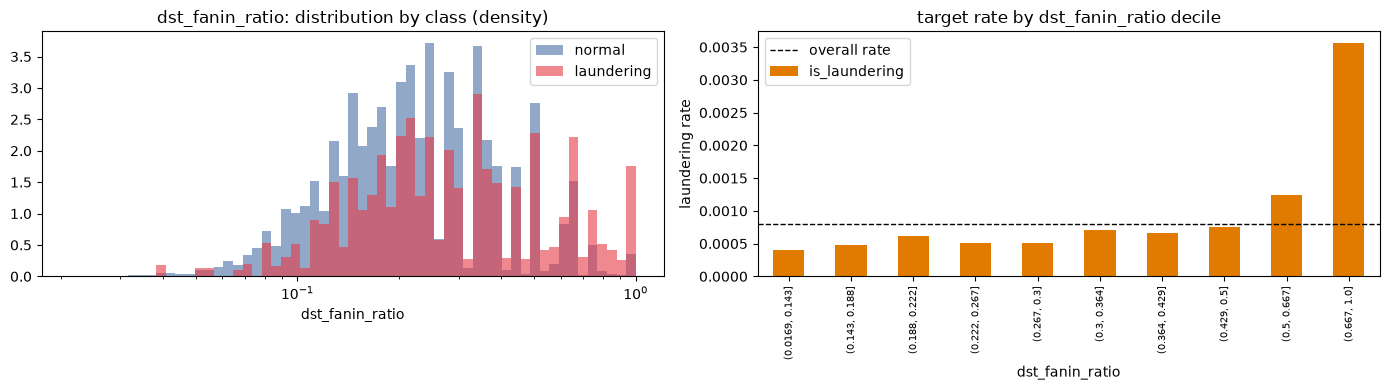

is_laundering,0,1
count,2.601352e+06,2139.000000
mean,3.556392e-01,0.499787
std,1.989699e-01,0.269811
min,1.785714e-02,0.040000
25%,2.000000e-01,0.272727
50%,3.000000e-01,0.444444
75%,5.000000e-01,0.666667
95%,7.500000e-01,1.000000
99%,1.000000e+00,1.000000
max,1.000000e+00,1.000000


In [71]:
print("NaN share:", train.src_fanout_ratio.isna().mean())
explore_numeric(train, "dst_fanin_ratio")

**Result**

|  | expected under H₀ | observed |
|---|---|---|
| cross-currency, laundering | 38.5 | **0** |

- Chi-square: χ² = 38.01, p = 7.03 × 10⁻¹⁰
- Fisher's exact: OR = 0.0000, p = 3.47 × 10⁻¹⁷

H₀ rejected at α = 0.01 by both tests. The odds ratio of exactly zero reflects
the empty cell — no laundering transaction in the training data crosses
currencies.

**Interpretation**

The association is real, not sampling noise. But significance establishes only
that the pattern is unlikely under independence — it does not make the feature
useful.

Two reasons to reject it despite significance:

1. **Direction contradicts domain knowledge.** Cross-currency movement is a
   recognised layering technique; a protective effect is not plausible
   behaviour.
2. **A perfectly empty cell across 47,865 rows** is characteristic of a
   generator constraint, not a behavioural tendency. Real data would show
   *some* overlap.

A model trained on this would learn "cross-currency ⇒ safe" and would fail on
any data where that constraint does not hold.

**Decision**

Drop `is_cross_currency` and `amount_delta`. Exclude self-loop rows from
training rather than retaining the flag.

NaN share: 0.2600897113334418


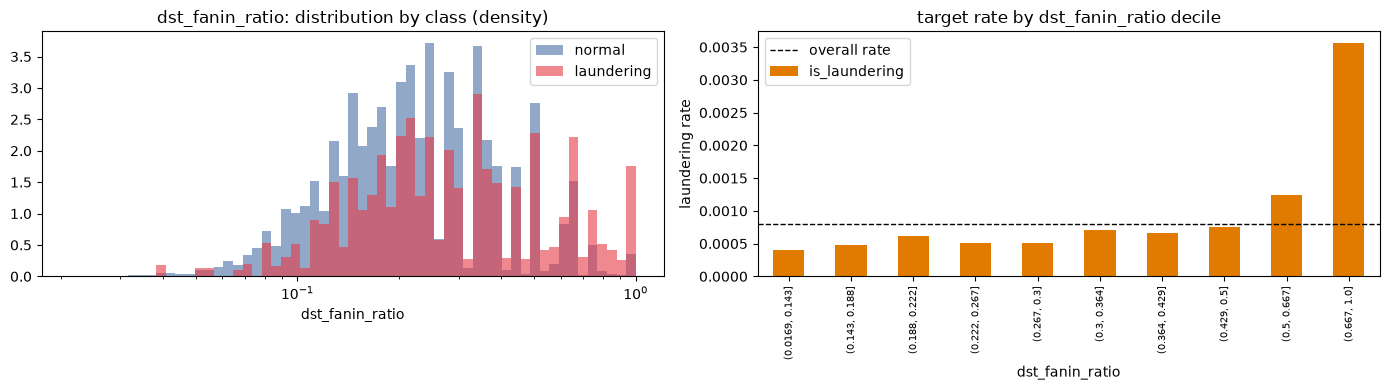

is_laundering,0,1
count,2.601352e+06,2139.000000
mean,3.556392e-01,0.499787
std,1.989699e-01,0.269811
min,1.785714e-02,0.040000
25%,2.000000e-01,0.272727
50%,3.000000e-01,0.444444
75%,5.000000e-01,0.666667
95%,7.500000e-01,1.000000
99%,1.000000e+00,1.000000
max,1.000000e+00,1.000000


In [72]:
print("NaN share:", train.src_fanout_ratio.isna().mean())
explore_numeric(train, "dst_fanin_ratio")

In [73]:
train.columns

Index(['timestamp', 'src_bank', 'src_account', 'dst_bank', 'dst_account', 'amount_received', 'currency_received', 'amount_paid',
       'currency_paid', 'payment_format', 'is_laundering', 'is_self_loop', 'is_cross_currency', 'amount_delta', 'is_burn_in',
       'src_entity_type', 'src_bank_country', 'dst_entity_type', 'dst_bank_country', 'src_secs_since_last', 'dst_secs_since_last',
       'src_secs_since_last_log', 'src_rapid_txn', 'src_dormant_wake', 'src_unique_dst_prior', 'dst_unique_src_prior',
       'src_txn_count_prior', 'dst_txn_count_prior', 'src_fanout_ratio', 'dst_fanin_ratio'],
      dtype='object')

In [74]:
# amount normalised within currency  (40x spread - second strongest)
train["amt_pct_ccy"] = (
    train.groupby("currency_paid", observed=True).amount_paid.rank(pct=True)
)

# deviation from the account's own geometric mean (3.5x)
train["src_log_amount"] = np.log1p(train.amount_paid)
g = train.groupby("src_account", sort=False)
prior_logmean = (
    (g.src_log_amount.cumsum() - train.src_log_amount)
    / train.src_txn_count_prior.replace(0, np.nan)
)
train["src_log_dev"] = np.where(
    train.src_txn_count_prior >= 3,
    train.src_log_amount - prior_logmean,
    np.nan,
)

# time (6x)
train["hour"] = train.timestamp.dt.hour
train["hour_sin"] = np.sin(2 * np.pi * train.hour / 24)
train["hour_cos"] = np.cos(2 * np.pi * train.hour / 24)
train["is_hour_zero"] = train.hour == 0

# fan-in threshold flag (8.7x in top decile)
train["dst_high_fanin"] = train.dst_fanin_ratio > 0.667

In [75]:
train.columns

Index(['timestamp', 'src_bank', 'src_account', 'dst_bank', 'dst_account', 'amount_received', 'currency_received', 'amount_paid',
       'currency_paid', 'payment_format', 'is_laundering', 'is_self_loop', 'is_cross_currency', 'amount_delta', 'is_burn_in',
       'src_entity_type', 'src_bank_country', 'dst_entity_type', 'dst_bank_country', 'src_secs_since_last', 'dst_secs_since_last',
       'src_secs_since_last_log', 'src_rapid_txn', 'src_dormant_wake', 'src_unique_dst_prior', 'dst_unique_src_prior',
       'src_txn_count_prior', 'dst_txn_count_prior', 'src_fanout_ratio', 'dst_fanin_ratio', 'amt_pct_ccy', 'src_log_amount', 'src_log_dev',
       'hour', 'hour_sin', 'hour_cos', 'is_hour_zero', 'dst_high_fanin'],
      dtype='object')

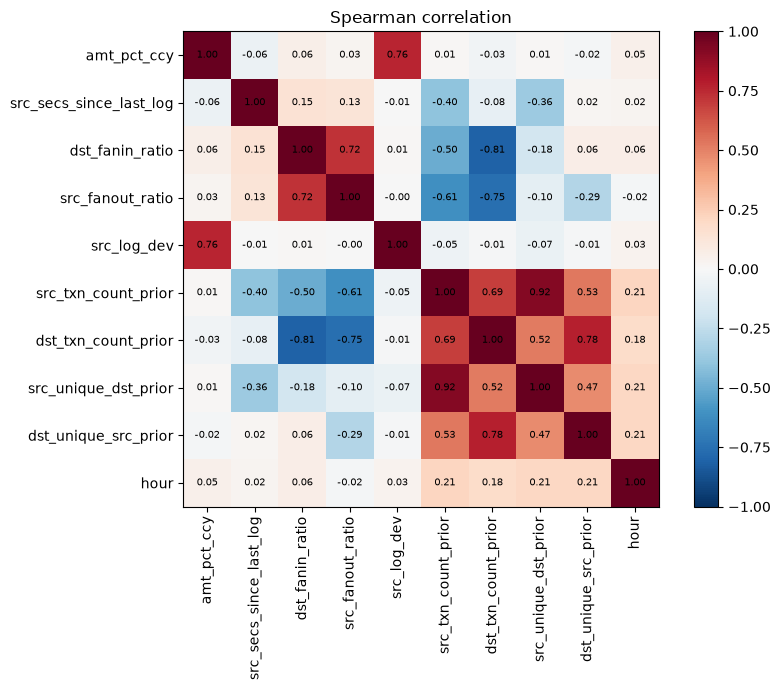

pairs above 0.8:
src_txn_count_prior  src_unique_dst_prior    0.915625
dst_fanin_ratio      dst_txn_count_prior     0.809316
dtype: float64


In [76]:
CANDIDATES = [
    "amt_pct_ccy",
    "src_secs_since_last_log",
    "dst_fanin_ratio",
    "src_fanout_ratio",
    "src_log_dev",
    "src_txn_count_prior",
    "dst_txn_count_prior",
    "src_unique_dst_prior",
    "dst_unique_src_prior",
    "hour",
]

corr = train[CANDIDATES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CANDIDATES))); ax.set_xticklabels(CANDIDATES, rotation=90)
ax.set_yticks(range(len(CANDIDATES))); ax.set_yticklabels(CANDIDATES)
for i in range(len(CANDIDATES)):
    for j in range(len(CANDIDATES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im)
plt.title("Spearman correlation")
plt.tight_layout(); plt.show()

high = (corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack().sort_values(ascending=False))
print("pairs above 0.8:")
print(high[high > 0.8])

## 13. Correlation — redundancy check

Spearman rather than Pearson: these features are heavily skewed and several
relationships are monotonic but not linear.

**Pairs above 0.7**

| pair | ρ | why |
|---|---|---|
| `src_unique_dst_prior` / `src_txn_count_prior` | 0.92 | numerator and denominator of the fan-out ratio |
| `dst_txn_count_prior` / `dst_fanin_ratio` | −0.81 | larger denominator drives the ratio down |
| `dst_txn_count_prior` / `dst_unique_src_prior` | 0.78 | same relationship, incoming side |
| `amt_pct_ccy` / `src_log_dev` | 0.76 | both amount-based: large for the currency usually means large for the account |
| `dst_fanin_ratio` / `src_fanout_ratio` | 0.72 | accounts with diverse senders tend to have diverse receivers |

**Decisions**

- **Drop the four raw counts** (`src_txn_count_prior`, `dst_txn_count_prior`,
  `src_unique_dst_prior`, `dst_unique_src_prior`). They are the components of
  the ratios and add no independent information.
- **Keep both fan ratios** despite ρ = 0.72. They describe opposite ends of a
  laundering chain — scatter on the way out, gather on the way in — and the
  correlation reflects a shared population of highly-connected accounts rather
  than the same measurement twice. Expect their SHAP importances to split
  unpredictably.
- **`src_log_dev` is marginal.** ρ = 0.76 with a much stronger feature.
  Retained for now; test whether removing it changes PR-AUC.
- **`src_secs_since_last_log` correlates with nothing above 0.40** — it carries
  genuinely independent information, consistent with it being the strongest
  single feature.

---

## 14. Final feature set

| feature | spread | shape | source |
|---|---|---|---|
| `src_secs_since_last_log` | 60× | U-shaped | timing |
| `amt_pct_ccy` | 40× | band | amount |
| `dst_fanin_ratio` | 8.7× | threshold | network |
| `payment_format` | 7.3× | categorical | raw |
| `hour_sin` / `hour_cos` | 6× | cyclical | time |
| `src_fanout_ratio` | 4.2× | threshold | network |
| `src_log_dev` | 3.5× | monotonic | behaviour |
| `src_rapid_txn` | 3.3× | boolean | timing |
| `src_dormant_wake` | 10.3× | boolean | timing |
| `dst_high_fanin` | — | boolean | network |
| `is_hour_zero` | — | boolean | data quality |
| entity type / bank country (×4) | ~1.3× | categorical | account |

**Rejected, with reason**

| feature | reason |
|---|---|
| `is_cross_currency`, `amount_delta` | 0 positives in 47,865 rows; χ² p=7e-10, Fisher p=3.5e-17. Real association, wrong direction — simulator artifact |
| `is_self_loop` | 0 positives; exclude those rows instead |
| `amt_logz_ccy`, `log_amount` | ρ = 0.955 with `amt_pct_ccy` |
| `src_log_dev_abs` | 2.2× vs 3.5× signed — discards direction |
| `src_amount_vs_own_mean` | superseded; arithmetic mean inflated by outliers |
| `src_is_new`, `dst_is_new` | mechanical artifact, direction contradicts AML practice |
| `day_of_week` | 10-day window, 1–2 observations per weekday |
| four raw prior-counts | components of the ratios, ρ up to 0.92 |

**Training row exclusions:** Reinvestment, Wire, self-loops, burn-in period —
all zero or near-zero positives.

---

## 15. What this means for modelling

**1. Not one top feature is linear-monotonic.**

Amount is a band. Timing is U-shaped. Fan-in and fan-out are thresholds.
Payment format is categorical. A linear model cannot represent "both extremes
are risky" — it can only learn one direction.

→ **XGBoost as primary model. Logistic regression as an interpretable baseline
for comparison, not as a contender.**

**2. Metrics must suit a 0.08% positive rate.**

ROC-AUC will look flattering and mean little.

→ **PR-AUC as headline, plus recall at a fixed alert budget** — if
investigators review 500 alerts a day, what share of laundering is caught?
That is the question an AML team actually asks.

**3. Cost asymmetry favours recall.**

A missed STR is a regulatory failure; a false positive costs investigator
time. Threshold selection should target a recall level and report the
precision cost, not default to 0.5.

**4. A rules baseline comes before the model.**

Detection rules are the incumbent in any real AML function. The model's
result should be stated as lift *over rules*, not as a standalone AUC.

---

## 16. Known limitations

**Simulator artifacts.** Zero laundering on Wire, Reinvestment and
cross-currency transactions are properties of the generator, not of banking.
All three are primary laundering channels in reality. Any model trained here
inherits those blind spots.

**Window dependence.** The file spans 10 days. The dormancy threshold
(200,000s ≈ 2.3 days) is ~23% of the observation window and would need
refitting on longer data.

**Timestamp resolution.** Timestamps are minute-granular — thresholds of 10s,
30s and 60s return identical results. "Within 60 seconds" means *same or
adjacent minute*.

**Chain truncation.** Chains beginning near day 10 are cut by the file
boundary, so some positives are partial patterns. The model is trained largely
on completed chains; in production it would see chains still in progress, and
recall on in-flight laundering would likely be lower.

**Offline/online mismatch.** Features are computed batch-wise over full
history. Production would need account aggregates maintained incrementally in
a feature store. The definitions here are the specification the online store
must reproduce — keeping them consistent is the main train-serve skew risk.

---

